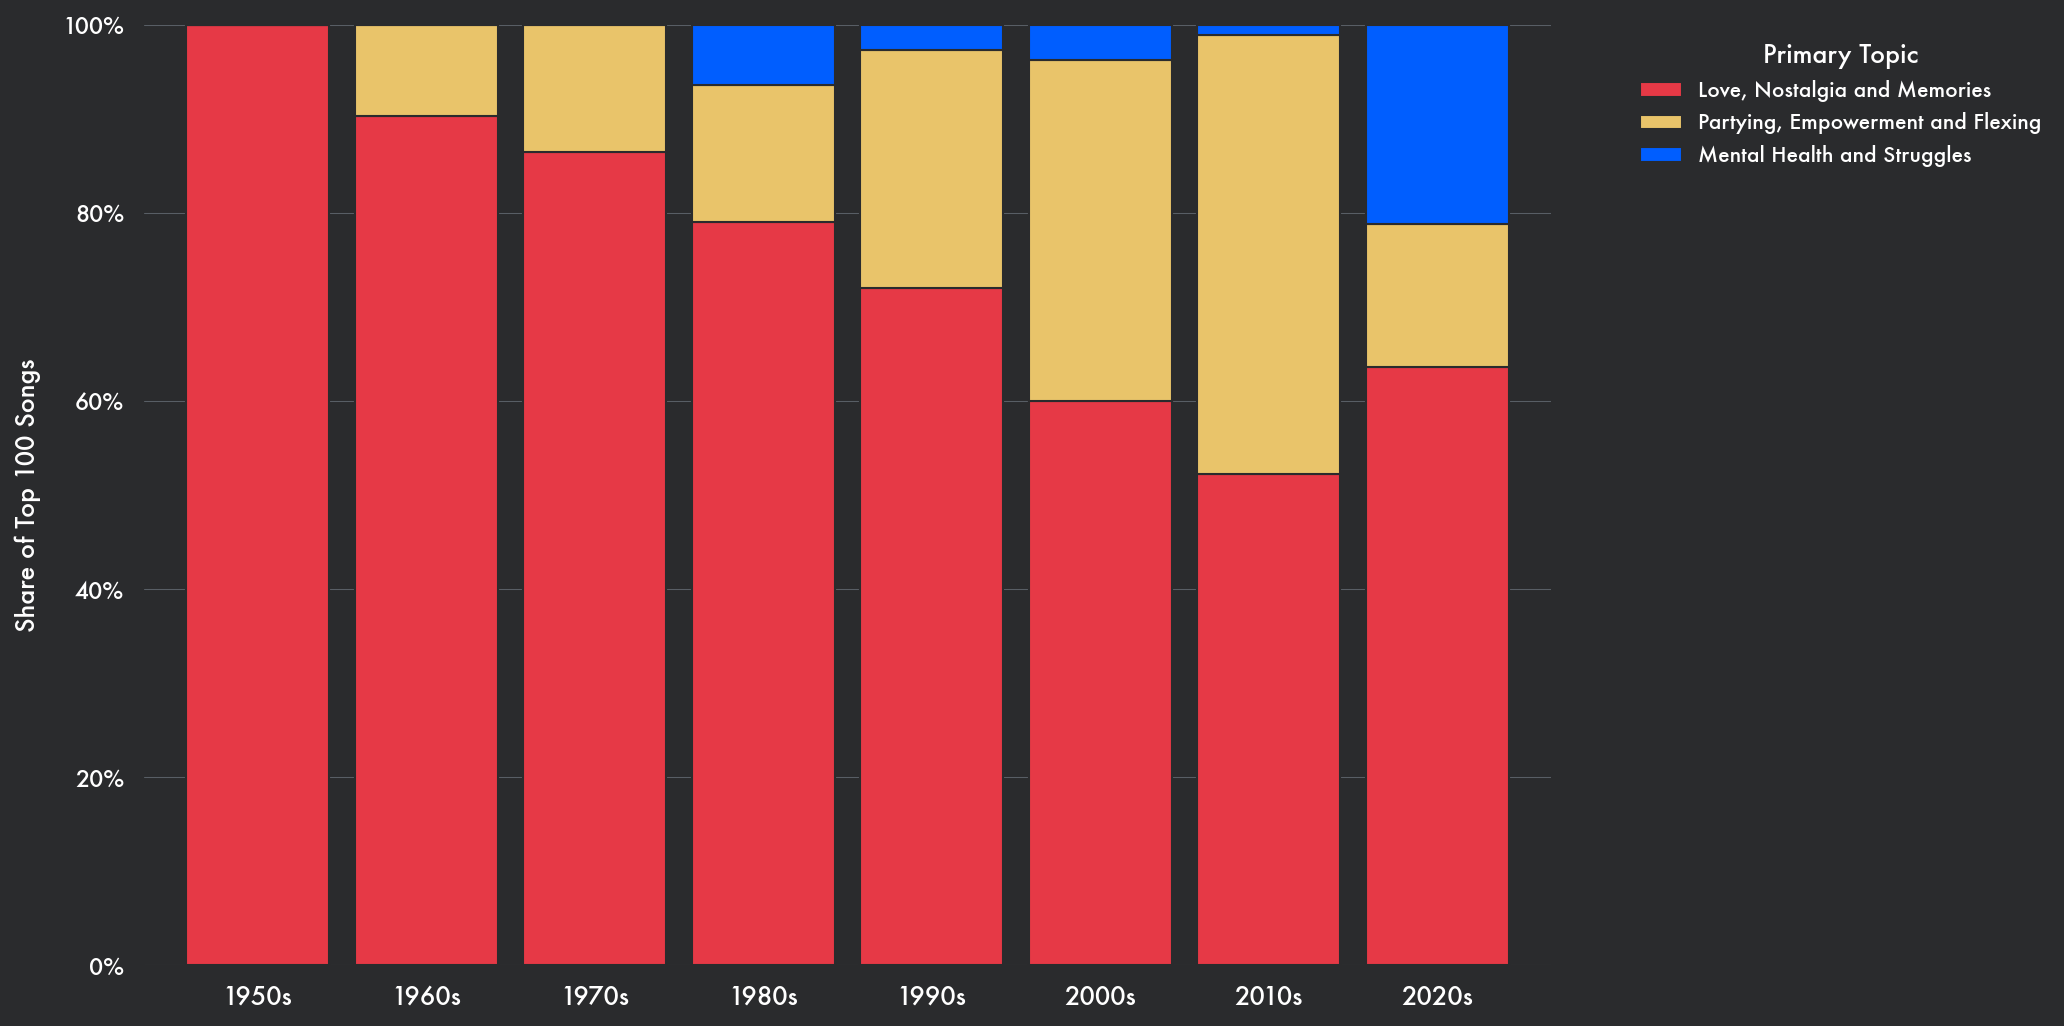

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.font_manager as fm
import json

with open('config.json', 'r') as f:
    config = json.load(f)

# Load colors from config
BG_COLOR = config["colors"]["BG_COLOR"]
TITLE_COLOR = config["colors"]["TITLE_COLOR"]
TEXT_COLOR = config["colors"]["TEXT_COLOR"]
US_COLOR = config["colors"]["US_COLOR"]
CH_COLOR = config["colors"]["CH_COLOR"]
GRID_COLOR = config["colors"]["GRID_COLOR"]
ACCENT_COLOR = config["colors"]["ACCENT_COLOR"]
TOPIC_COLORS = config["colors"]["TOPIC_COLORS"]

# Load fonts from config
font_path_title = "style/" + config["fonts"]["title_font_path"]
font_path_main = "style/" + config["fonts"]["main_font_path"]

fm.fontManager.addfont(font_path_title)
fm.fontManager.addfont(font_path_main)

title_font_name = fm.FontProperties(fname=font_path_title).get_name()
main_font_name = fm.FontProperties(fname=font_path_main).get_name()


def prepare_topic_data(df_usa: pd.DataFrame, df_ch: pd.DataFrame):
    """Combines both datasets, groups specified topics, filters by confidence and calculates decade percentages."""

    # Combine USA and Switzerland data
    df = pd.concat([df_usa, df_ch], ignore_index=True)
    
    # Filter out songs where the model was very unsure
    df_filtered = df[df['Topic_Score'] >= 0.5].copy()
    
    topic_mapping = {
        "Romantic Love": "Love, Nostalgia and Memories",
        "Heartbreak and Breakup": "Love, Nostalgia and Memories",
        "Nostalgia and Memories": "Love, Nostalgia and Memories",

        "Mental Health and Struggles": "Mental Health and Struggles",
        "Social Issues and Protest": "Mental Health and Struggles",

        "Wealth, Success and Flexing": "Partying, Empowerment and Flexing",
        "Empowerment and Self-Confidence": "Partying, Empowerment and Flexing",
        "Escapism and Partying": "Partying, Empowerment and Flexing"
    }

    df_filtered['Topic'] = df_filtered['Topic'].replace(topic_mapping)
    
    df_filtered['Decade'] = (df_filtered['Year'] // 10) * 10
    
    # Count occurrences of each topic per decade
    topic_counts = df_filtered.groupby(['Decade', 'Topic']).size().unstack(fill_value=0)
    
    # Convert counts to percentages
    topic_percentages = topic_counts.div(topic_counts.sum(axis=1), axis=0) * 100
    
    # Ensure columns are ordered by the keys
    ordered_topics = [t for t in TOPIC_COLORS.keys() if t in topic_percentages.columns]
    topic_percentages = topic_percentages[ordered_topics]
    
    # Generate the ordered list of colors for the plot
    colors = [TOPIC_COLORS[topic] for topic in ordered_topics]
    
    return topic_percentages, colors


def format_topic_aesthetics(ax: plt.Axes, topic_percentages: pd.DataFrame):
    """Applies theme, fonts and annotations."""

    # Remove all spines
    sns.despine(left=True, top=True, right=True, bottom=True)
    
    # Formatting y-axis and grid
    ax.grid(color=GRID_COLOR, linestyle='-', linewidth=0.5, axis='y', alpha=0.7)
    ax.grid(False, axis='x')
    
    # Update y-ticks to show percentages
    yticks = ax.get_yticks()
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{int(y)}%" for y in yticks], color=TEXT_COLOR)
    ax.set_ylabel('Share of Top 100 Songs', fontsize=12, color=TEXT_COLOR, labelpad=10)

    # Formatting x-axis
    decades_labels = [f"{int(d)}s" for d in topic_percentages.index]
    ax.set_xticklabels(decades_labels, rotation=0, fontsize=12, color=TEXT_COLOR, fontweight='bold')
    ax.set_xlabel('') 
    
    # Tick colors
    ax.tick_params(axis='x', colors=TEXT_COLOR)
    ax.tick_params(axis='y', colors=TEXT_COLOR)

    # Legend formatting
    legend = ax.legend(title='Primary Topic', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=10, title_fontsize=12)
    plt.setp(legend.get_texts(), color=TEXT_COLOR)
    plt.setp(legend.get_title(), color=TEXT_COLOR)


def create_topic_evolution_chart(df_usa: pd.DataFrame, df_ch: pd.DataFrame):
    # Get prepped data
    topic_percentages, colors = prepare_topic_data(df_usa, df_ch)

    # Canvas setup
    sns.set_theme(style="whitegrid", rc={
        "axes.facecolor": BG_COLOR, 
        "figure.facecolor": BG_COLOR,
        "font.family": main_font_name  
    })
    
    fig, ax = plt.subplots(figsize=(14, 7), dpi=150)

    # Plotting chart
    topic_percentages.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.85, edgecolor=BG_COLOR, linewidth=1)

    # Apply styling, labels and annotations
    format_topic_aesthetics(ax, topic_percentages)

    plt.tight_layout()
    return fig


if __name__ == "__main__":
    # load datasets
    df_usa = pd.read_csv('data/US/songs_analyzed.csv')
    df_ch = pd.read_csv('data/CH/songs_analyzed.csv') 

    # Generate and show plot
    topic_fig = create_topic_evolution_chart(df_usa, df_ch)
    plt.show()

    # Save the chart
    topic_fig.savefig('chartsPNG/chart2.png', dpi=300, bbox_inches='tight')